# 3sensacionalismo: Evaluación Comparativa de 3 Modelos de Sensacionalismo

Este cuadernillo evalúa y compara el rendimiento de **3 modelos** para la detección de sensacionalismo utilizando **3 conjuntos de datos completos y corregidos**, optimizado para ejecución en **GPU (NVIDIA GeForce GTX 1650 con aceleración CUDA y precisión FP16)**.

### Modelos Evaluados:
1. **Modelo 1 (Base BERT / JJNeila)**: `JJNeila/bert-spanish-sensationalism-oss` (Clasificación supervisada directa).
2. **Modelo 2 (Zero-Shot mDeBERTa)**: `MoritzLaurer/mDeBERTa-v3-base-mnli-xnli` (Agrupación Semántica: `sensacionalista` + `amarillista` vs `noticia objetiva` + `riguroso`).
3. **Modelo 3 (Emociones pysentimiento)**: `pysentimiento/robertuito-emotion-analysis` (Umbral Emocional: `fear` + `surprise` + `anger` > 0.45 y `others` < 0.30).

### Bases de Datos Evaluadas (Versión Completa y Corregida):
- **Base 1 (Salud)**: `dataset_Salud.csv` (2.200 registros de noticias biomédicas y de salud: 1.120 clase 0, 1.080 clase 1).
- **Base 2 (Amarillismo)**: `dataset_Amarillismo.csv` (202 registros reales balanceados: 101 No Amarillista / 101 Amarillista, unificando prensa real, corpus anotado y fuentes digitales).
- **Base 3 (Creado con IA)**: 70 registros sintéticos multitemáticos balanceados (35 clase 0 y 35 clase 1) en 10 áreas temáticas contrastivas.


In [1]:
# 1. Instalación de dependencias en el entorno o Google Colab
# !pip install -q transformers torch pandas scikit-learn seaborn matplotlib pysentimiento accelerate


In [2]:
import pandas as pd
import numpy as np
import torch
import io
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# Configuración del estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Selección del dispositivo y tipo de datos para optimización en GPU
device = 0 if torch.cuda.is_available() else -1
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"Dispositivo seleccionado: {'GPU (cuda:0) - ' + device_name if device == 0 else 'CPU'}")
print(f"Precisión de tensores: {'FP16 (Half)' if torch_dtype == torch.float16 else 'FP32 (Single)'}")

# Directorios de exportación para guardar imágenes tanto en la carpeta local como en reportes
img_dirs = [
    "reportes/imagenes/comparativa_3_modelos"
]
for d in img_dirs:
    os.makedirs(d, exist_ok=True)


/home/ubuntu/Documentos/Tesis/venv_pipeline/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo seleccionado: GPU (cuda:0) - NVIDIA GeForce GTX 1650
Precisión de tensores: FP16 (Half)


## Carga y Preparación de los 3 Datasets Completos


In [3]:
# A. Dataset 1: Salud (2.200 registros)
paths_salud = [
    "dataset_Salud.csv",
    "/home/ubuntu/Documentos/Tesis/Modelos_Individuales/Sensacionalismo/dataset_Salud.csv",
    "/home/ubuntu/Documentos/Tesis/Datasets/sensacionalismo/dataset_Salud.csv"
]
path_salud = None
for p in paths_salud:
    if os.path.exists(p):
        path_salud = p
        break

df_salud = pd.read_csv(path_salud)
y_salud = df_salud['clase'].values
print(f"Dataset 1 (Salud) cargado: {len(df_salud)} registros. Balance de clases: {np.bincount(y_salud)}")

# B. Dataset 2: Amarillismo (202 registros reales balanceados: 101 Amarillista / 101 No Amarillista)
paths_amarillismo = [
    "dataset_Amarillismo.csv",
    "/home/ubuntu/Documentos/Tesis/Modelos_Individuales/Sensacionalismo/dataset_Amarillismo.csv",
    "/home/ubuntu/Documentos/Tesis/Datasets/sensacionalismo/dataset_Amarillismo.csv"
]
path_amarillismo = None
for p in paths_amarillismo:
    if os.path.exists(p):
        path_amarillismo = p
        break

df_amarillismo = pd.read_csv(path_amarillismo)
col_text_ama = 'Titular' if 'Titular' in df_amarillismo.columns else ('encabezado' if 'encabezado' in df_amarillismo.columns else df_amarillismo.columns[0])
col_class_ama = 'Amarillismo' if 'Amarillismo' in df_amarillismo.columns else ('clase' if 'clase' in df_amarillismo.columns else df_amarillismo.columns[-1])

mapping = {'No Amarillista': 0, 'Amarillista': 1, 'No sensacionalista': 0, 'Sensacionalista': 1, '0': 0, '1': 1}
if df_amarillismo[col_class_ama].dtype != int:
    y_amarillismo = df_amarillismo[col_class_ama].astype(str).str.strip().map(mapping).fillna(0).astype(int).values
elif False:
    y_amarillismo = df_amarillismo[col_class_ama].map({'No Amarillista': 0, 'Amarillista': 1, 'No sensacionalista': 0, 'Sensacionalista': 1}).fillna(0).astype(int).values
else:
    y_amarillismo = df_amarillismo[col_class_ama].astype(int).values

print(f"Dataset 2 (Amarillismo) cargado: {len(df_amarillismo)} registros. Balance de clases: {np.bincount(y_amarillismo)}")

# C. Dataset 3: Creado con IA (70 registros sintéticos balanceados en 10 áreas temáticas)
csv_data = """Texto,Tema,Clase
"¡El fin de la humanidad! La nueva inteligencia artificial que destruirá millones de empleos mañana mismo. Expertos advierten que el apocalipsis digital ya comenzó y nadie está a salvo.","Tecnología","Sensacionalista"
"Empresa de tecnología anuncia un nuevo modelo de lenguaje que podría automatizar tareas administrativas. El reporte técnico indica un posible impacto gradual en el sector empresarial.","Tecnología","No sensacionalista"
"¡Tu celular te está espiando! Descubre cómo la cámara secreta graba todas tus conversaciones y las envía a los gobiernos sin tu permiso.","Tecnología","Sensacionalista"
"Especialistas en ciberseguridad recomiendan revisar los permisos de las aplicaciones móviles para proteger los datos personales de los usuarios.","Tecnología","No sensacionalista"
"¡Escándalo brutal! Político es captado destruyendo pruebas de corrupción en una fiesta clandestina con delincuentes peligrosos.","Política","Sensacionalista"
"La comisión parlamentaria citó al funcionario público para responder sobre presuntas irregularidades en el presupuesto de infraestructura.","Política","No sensacionalista"
"¡Fraude colosal! El gobierno planea confiscar todos los depósitos bancarios de los ciudadanos para pagar una deuda secreta este fin de semana.","Política","Sensacionalista"
"El Banco Central emitió un comunicado oficial asegurando la estabilidad del sistema financiero tras las fluctuaciones del mercado internacional.","Política","No sensacionalista"
"¡Terremoto devastador! La falla tectónica que partirá al país en dos y hundirá ciudades enteras en las próximas horas.","Ciencia & Clima","Sensacionalista"
"El instituto geofísico monitorea la actividad sísmica en la región andina tras registrarse un temblor de magnitud moderada sin daños reportados.","Ciencia & Clima","No sensacionalista"
"¡Tóxicos en tu ropa! Las marcas de moda más famosas usan ácidos mortales que están quemando la piel de millones.","Moda","Sensacionalista"
"Diseñador local presentó su nueva colección de invierno destacando el uso de materiales reciclados y sostenibles.","Moda","No sensacionalista"
"¡Ola de calor asesina! Temperaturas extremas derretirán el asfalto y causarán muertes instantáneas si sales de tu casa mañana.","Ciencia & Clima","Sensacionalista"
"Las autoridades declararon alerta amarilla ante el aumento gradual de las temperaturas en la región central del país.","Ciencia & Clima","No sensacionalista"
"¡Universidades de cartón! Estudiantes descubren que sus diplomas son totalmente falsos tras años de pagar fortunas a mafias académicas.","Educación","Sensacionalista"
"Universidad pública inaugura un nuevo centro de investigación tecnológica con fondos otorgados por organismos internacionales.","Educación","No sensacionalista"
"¡El metro es una trampa mortal! Fallas eléctricas inminentes amenazan con electrocutar a miles de pasajeros en hora pico.","Transporte","Sensacionalista"
"La línea de metro suspenderá su servicio en tres estaciones durante el fin de semana por mantenimiento preventivo en las vías.","Transporte","No sensacionalista"
"¡Actor enloquece en vivo! Golpea salvajemente a un presentador y amenaza con incendiar el estudio de grabación por completo.","Entretenimiento","Sensacionalista"
"La ceremonia de premios a la televisión concluyó con un homenaje a la trayectoria del reconocido director de cine independiente.","Entretenimiento","No sensacionalista"
"¡Gatos diabólicos! Una nueva enfermedad transmitida por felinos domésticos está dejando a familias enteras en coma profundo.","Mascotas","Sensacionalista"
"Veterinarios advierten sobre la importancia de desparasitar a las mascotas regularmente para prevenir enfermedades comunes.","Mascotas","No sensacionalista"
"¡Mafia de los alquileres! Propietarios sin escrúpulos expulsan a ancianos a la calle para cobrar el triple a extranjeros ricos.","Bienes Raíces","Sensacionalista"
"Nuevo proyecto de ley busca regular los precios de alquiler en zonas céntricas para facilitar el acceso a la vivienda.","Bienes Raíces","No sensacionalista"
"¡Maquillaje letal! El labial de moda que contiene plomo puro y está envenenando silenciosamente a las jóvenes del país.","Moda","Sensacionalista"
"Empresa de cosméticos retiró voluntariamente un lote de sus productos tras detectar leves inconsistencias en el empaquetado.","Moda","No sensacionalista"
"¡Huracán apocalíptico! Vientos destructores borrarán la costa del mapa en menos de veinticuatro horas, huye mientras puedas.","Ciencia & Clima","Sensacionalista"
"Protección civil recomienda asegurar puertas y ventanas ante la posible llegada de ráfagas de viento a la zona costera.","Ciencia & Clima","No sensacionalista"
"¡Profesores acosadores! La red secreta de maestros que vigila a los alumnos por cámaras ocultas en los baños del colegio.","Educación","Sensacionalista"
"Sindicato de maestros llegó a un acuerdo salarial con el gobierno local tras dos semanas de negociaciones formales.","Educación","No sensacionalista"
"¡Taxis de la muerte! Conductores psicópatas están secuestrando pasajeros a plena luz del día bajo la mirada cómplice de la policía.","Transporte","Sensacionalista"
"Plataforma de movilidad compartida ajustará sus tarifas en un cinco por ciento a partir del inicio del próximo mes.","Transporte","No sensacionalista"
"¡Ídolo juvenil hundido en las drogas! Fotos exclusivas lo muestran consumiendo sustancias letales en un antro de perdición.","Entretenimiento","Sensacionalista"
"La banda de rock confirmó las fechas de su próxima gira latinoamericana que iniciará a principios del año entrante.","Entretenimiento","No sensacionalista"
"¡Aves portadoras de la peste! Palomas mutantes están esparciendo un virus carnívoro desde los techos de la ciudad.","Mascotas","Sensacionalista"
"El zoológico municipal anunció el nacimiento de tres crías de flamenco como parte de su programa de conservación.","Mascotas","No sensacionalista"
"¡Burbuja a punto de estallar! Los precios de los apartamentos caerán a cero y perderás todos los ahorros de tu vida hoy.","Bienes Raíces","Sensacionalista"
"Expertos en economía sugieren que el mercado de oficinas tardará varios años en recuperar los niveles de ocupación previos a la crisis.","Bienes Raíces","No sensacionalista"
"¡Zapatos que mutilan! Deportivas de marca famosa están deformando los pies de los atletas causando amputaciones terribles.","Moda","Sensacionalista"
"Feria textil congrega a cientos de empresarios del sector para discutir las nuevas tendencias en exportación de prendas.","Moda","No sensacionalista"
"¡Inundación bíblica! Represas a punto de reventar ahogarán a pueblos enteros mientras los políticos escapan en helicópteros privados.","Ciencia & Clima","Sensacionalista"
"El nivel de los embalses se encuentra en un promedio estable tras las precipitaciones registradas durante el último mes.","Ciencia & Clima","No sensacionalista"
"¡Adoctrinamiento forzado! Libros de texto incluyen mensajes subliminales para que los niños odien a sus propios padres.","Educación","Sensacionalista"
"La facultad de ciencias sociales publicó un estudio sobre el impacto de la lectura comprensiva en el rendimiento académico.","Educación","No sensacionalista"
"¡Tren fantasma fuera de control! Una locomotora a toda velocidad se dirige al centro de la ciudad para causar una carnicería.","Transporte","Sensacionalista"
"Ministerio de transporte inauguró el nuevo puente colgante que conectará a las dos provincias más aisladas del sur.","Transporte","No sensacionalista"
"¡Divorcio sangriento! Pareja de Hollywood se enfrenta a cuchillazos por la custodia de sus hijos y su mansión de oro.","Entretenimiento","Sensacionalista"
"Festival de cine documental abre su convocatoria para recibir largometrajes producidos por jóvenes realizadores iberoamericanos.","Entretenimiento","No sensacionalista"
"¡Comida de mascotas envenenada! Croquetas de supermercado están matando a miles de perros en una agonía espantosa.","Mascotas","Sensacionalista"
"La venta de alimentos premium para mascotas experimentó un crecimiento sustained en los supermercados de cadena de la región.","Mascotas","No sensacionalista"
"¡Derrumbe inminente! Tu edificio está construido con arena y colapsará sobre tu cabeza al primer temblor leve.","Bienes Raíces","Sensacionalista"
"Fondo de inversión adquiere un complejo de oficinas en el distrito financiero para destinarlo a espacios de trabajo colaborativo.","Bienes Raíces","No sensacionalista"
"¡Pantalones cancerígenos! La tela sintética que absorbe radiación y te condena a una muerte lenta y dolorosa e irreversible.","Moda","Sensacionalista"
"Organización no gubernamental promueve el intercambio de prendas usadas para reducir el impacto ambiental de la industria textil.","Moda","No sensacionalista"
"¡Sequía mortal! El agua potable se agotará mañana mismo y comenzarás a morir de sed en tu propia casa sin ayuda.","Ciencia & Clima","Sensacionalista"
"Agricultores implementan nuevos sistemas de riego por goteo para optimizar el uso de recursos hídricos en época de sequía.","Ciencia & Clima","No sensacionalista"
"¡Ciborgs en las aulas! Niños con chips cerebrales están reemplazando a los estudiantes humanos en un experimento gubernamental macabro.","Educación","Sensacionalista"
"Foro internacional debate los retos de integrar herramientas de inteligencia artificial en la evaluación de estudiantes universitarios.","Educación","No sensacionalista"
"¡Quiebra nacional inminente! Todos los bancos cerrarán sus puertas y la inflación devorará los salarios en cuestión de horas.","Economía","Sensacionalista"
"El Ministerio de Economía anunció un ajuste en las tasas de interés para contener el incremento inflacionario trimestral.","Economía","No sensacionalista"
"¡Bancarrotas en cadena! Millones de familias perderán sus ahorros por el colapso financiero total del sistema crediticio.","Economía","Sensacionalista"
"La superintendencia financiera reportó un incremento moderado en los índices de morosidad comercial durante el último semestre.","Economía","No sensacionalista"
"¡Tragedia en la cancha! Violencia desmedida y sangre tiñen el clásico de fútbol tras batalla campal entre hinchas armados.","Deportes","Sensacionalista"
"El comité disciplinario de la liga sancionó a dos clubes con multas económicas por disturbios menores en las tribunas.","Deportes","No sensacionalista"
"¡Escándalo arbitral histórico! Árbitro vendido comete fraude descarado para coronar al equipo más odiado del país.","Deportes","Sensacionalista"
"La federación de fútbol evaluó el uso del sistema de videoarbitraje tras las polémicas decisiones de la jornada deportiva.","Deportes","No sensacionalista"
"¡Asteroide mortal se aproxima a la Tierra! La NASA oculta que un impacto devastador destruirá la civilización la próxima semana.","Ciencia & Clima","Sensacionalista"
"La agencia espacial publicó los datos de seguimiento orbital de un asteroide cercano que pasará a una distancia segura de la órbita lunar.","Ciencia & Clima","No sensacionalista"
"¡El sol se está apagando! Científicos alertan que una era de hielo perpetua congelará a los seres humanos este mismo año.","Ciencia & Clima","Sensacionalista"
"Investigadores solares reportan un descenso periódico en las manchas solares acorde a los ciclos normales de actividad heliomagnética.","Ciencia & Clima","No sensacionalista"
"""
df_ia = pd.read_csv(io.StringIO(csv_data))
y_ia = df_ia['Clase'].map({'No sensacionalista': 0, 'Sensacionalista': 1}).values
print(f"Dataset 3 (IA) cargado: {len(df_ia)} registros. Balance de clases: {np.bincount(y_ia)}")

# Estructura global para acumular métricas finales
resultados_globales = []
def registrar_metricas(modelo, dataset_name, y_true, y_pred, tiempo_total=0.0):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    latencia_ms = (tiempo_total / len(y_true)) * 1000 if len(y_true) > 0 else 0.0
    resultados_globales.append({
        "Modelo": modelo,
        "Dataset": dataset_name,
        "N° Registros": len(y_true),
        "Accuracy": round(acc, 4),
        "Macro Precision": round(prec, 4),
        "Macro Recall": round(rec, 4),
        "Macro F1-Score": round(f1, 4),
        "Tiempo Total (s)": round(tiempo_total, 2),
        "Latencia (ms)": round(latencia_ms, 1)
    })

def guardar_matriz_confusion(cm, title, filename, cmap='Blues'):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
                xticklabels=['Pred 0 (No Sens.)', 'Pred 1 (Sens.)'],
                yticklabels=['Real 0 (No Sens.)', 'Real 1 (Sens.)'], ax=ax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción del Modelo')
    ax.set_ylabel('Etiqueta Real')
    plt.tight_layout()
    for d in img_dirs:
        filepath = os.path.join(d, filename)
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()


Dataset 1 (Salud) cargado: 2200 registros. Balance de clases: [1120 1080]
Dataset 2 (Amarillismo) cargado: 202 registros. Balance de clases: [101 101]
Dataset 3 (IA) cargado: 70 registros. Balance de clases: [35 35]


--- 
# MODELO 1: Base BERT (JJNeila/bert-spanish-sensationalism-oss)


In [4]:
print("Cargando Modelo 1: JJNeila/bert-spanish-sensationalism-oss...")
modelo1_pipeline = pipeline("text-classification", model="JJNeila/bert-spanish-sensationalism-oss", device=device, torch_dtype=torch_dtype)
print("¡Modelo 1 cargado correctamente en GPU!")

def evaluar_modelo1(textos, batch_size=32):
    res = modelo1_pipeline(textos, truncation=True, max_length=512, batch_size=batch_size)
    return [1 if r['label'] in ['LABEL_1', 'Sensacionalista'] else 0 for r in res]


Cargando Modelo 1: JJNeila/bert-spanish-sensationalism-oss...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|                                 | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|█████████████████████| 201/201 [00:00<00:00, 6714.84it/s]

¡Modelo 1 cargado correctamente en GPU!


=== Modelo 1 - Dataset Salud (2.200 registros) - Tiempo: 32.96s ===
                        precision    recall  f1-score   support

No sensacionalista (0)     0.7617    0.1884    0.3021      1120
   Sensacionalista (1)     0.5273    0.9389    0.6753      1080

              accuracy                         0.5568      2200
             macro avg     0.6445    0.5636    0.4887      2200
          weighted avg     0.6466    0.5568    0.4853      2200



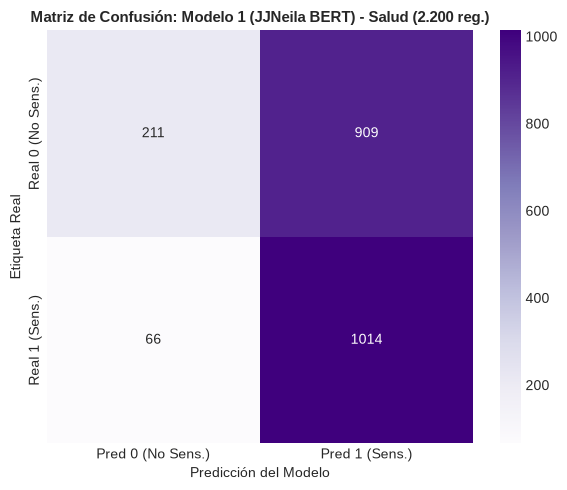

In [5]:
# Modelo 1 en Dataset 1: Salud (2.200 registros)
t0 = time.time()
pred_m1_salud = evaluar_modelo1(df_salud['encabezado'].tolist(), batch_size=32)
tiempo_m1_salud = time.time() - t0

registrar_metricas("Modelo 1 (BERT JJNeila)", "Dataset 1: Salud", y_salud, pred_m1_salud, tiempo_m1_salud)

print(f"=== Modelo 1 - Dataset Salud (2.200 registros) - Tiempo: {tiempo_m1_salud:.2f}s ===")
print(classification_report(y_salud, pred_m1_salud, target_names=['No sensacionalista (0)', 'Sensacionalista (1)'], digits=4))

cm_m1_salud = confusion_matrix(y_salud, pred_m1_salud)
guardar_matriz_confusion(cm_m1_salud, "Matriz de Confusión: Modelo 1 (JJNeila BERT) - Salud (2.200 reg.)", "cm_m1_salud.png", cmap='Purples')


=== Modelo 1 - Dataset Amarillismo (202 registros) - Tiempo: 3.31s ===
                    precision    recall  f1-score   support

No Amarillista (0)     0.7778    0.1386    0.2353       101
   Amarillista (1)     0.5272    0.9604    0.6807       101

          accuracy                         0.5495       202
         macro avg     0.6525    0.5495    0.4580       202
      weighted avg     0.6525    0.5495    0.4580       202



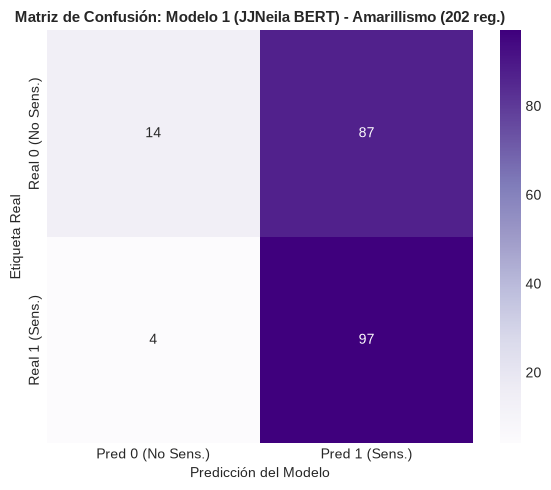

In [6]:
# Modelo 1 en Dataset 2: Amarillismo (202 registros reales balanceados)
t0 = time.time()
pred_m1_ama = evaluar_modelo1(df_amarillismo[col_text_ama].tolist(), batch_size=32)
tiempo_m1_ama = time.time() - t0

registrar_metricas("Modelo 1 (BERT JJNeila)", "Dataset 2: Amarillismo", y_amarillismo, pred_m1_ama, tiempo_m1_ama)

print(f"=== Modelo 1 - Dataset Amarillismo (202 registros) - Tiempo: {tiempo_m1_ama:.2f}s ===")
print(classification_report(y_amarillismo, pred_m1_ama, target_names=['No Amarillista (0)', 'Amarillista (1)'], digits=4))

cm_m1_ama = confusion_matrix(y_amarillismo, pred_m1_ama)
guardar_matriz_confusion(cm_m1_ama, "Matriz de Confusión: Modelo 1 (JJNeila BERT) - Amarillismo (202 reg.)", "cm_m1_amarillismo.png", cmap='Purples')


=== Modelo 1 - Dataset IA (70 registros) - Tiempo: 1.44s ===
                        precision    recall  f1-score   support

No sensacionalista (0)     1.0000    1.0000    1.0000        35
   Sensacionalista (1)     1.0000    1.0000    1.0000        35

              accuracy                         1.0000        70
             macro avg     1.0000    1.0000    1.0000        70
          weighted avg     1.0000    1.0000    1.0000        70



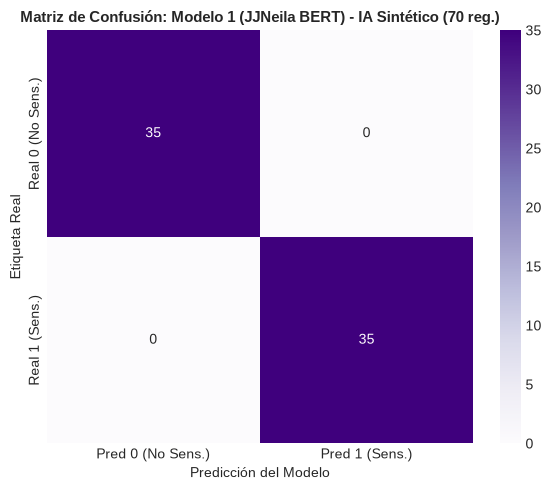

In [7]:
# Modelo 1 en Dataset 3: Creado con IA (70 registros)
t0 = time.time()
pred_m1_ia = evaluar_modelo1(df_ia['Texto'].tolist(), batch_size=32)
tiempo_m1_ia = time.time() - t0

registrar_metricas("Modelo 1 (BERT JJNeila)", "Dataset 3: IA Sintético", y_ia, pred_m1_ia, tiempo_m1_ia)

print(f"=== Modelo 1 - Dataset IA (70 registros) - Tiempo: {tiempo_m1_ia:.2f}s ===")
print(classification_report(y_ia, pred_m1_ia, target_names=['No sensacionalista (0)', 'Sensacionalista (1)'], digits=4))

cm_m1_ia = confusion_matrix(y_ia, pred_m1_ia)
guardar_matriz_confusion(cm_m1_ia, "Matriz de Confusión: Modelo 1 (JJNeila BERT) - IA Sintético (70 reg.)", "cm_m1_ia.png", cmap='Purples')

# Liberación de memoria VRAM
del modelo1_pipeline
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


--- 
# MODELO 2: Agrupación Semántica (mDeBERTa Zero-Shot)


In [8]:
print("Cargando Modelo 2: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli...")
modelo2_pipeline = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=device, torch_dtype=torch_dtype)
print("¡Modelo 2 Zero-Shot cargado correctamente en GPU!")

def evaluar_modelo2(textos, batch_size=16):
    labels = ["sensacionalista", "amarillista", "noticia objetiva", "riguroso"]
    res_list = modelo2_pipeline(textos, candidate_labels=labels, truncation=True, max_length=512, batch_size=batch_size)
    preds = []
    for res in res_list:
        scores = dict(zip(res["labels"], res["scores"]))
        bando_positivo = scores.get("sensacionalista", 0.0) + scores.get("amarillista", 0.0)
        bando_negativo = scores.get("noticia objetiva", 0.0) + scores.get("riguroso", 0.0)
        preds.append(1 if bando_positivo > bando_negativo else 0)
    return preds


Cargando Modelo 2: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli...


/home/ubuntu/Documentos/Tesis/venv_pipeline/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Loading weights:   0%|                                 | 0/202 [00:00<?, ?it/s]

Loading weights: 100%|█████████████████████| 202/202 [00:00<00:00, 7923.77it/s]

¡Modelo 2 Zero-Shot cargado correctamente en GPU!


=== Modelo 2 - Dataset Salud (2.200 registros) - Tiempo: 247.02s ===
                        precision    recall  f1-score   support

No sensacionalista (0)     0.7045    0.3768    0.4910      1120
   Sensacionalista (1)     0.5640    0.8361    0.6736      1080

              accuracy                         0.6023      2200
             macro avg     0.6343    0.6064    0.5823      2200
          weighted avg     0.6355    0.6023    0.5806      2200



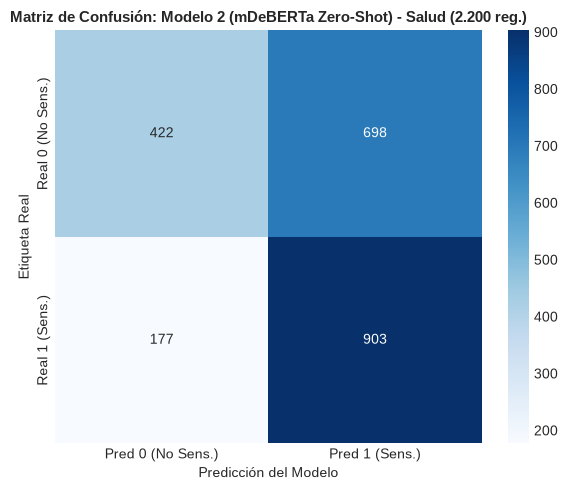

In [9]:
# Modelo 2 en Dataset 1: Salud (2.200 registros)
t0 = time.time()
pred_m2_salud = evaluar_modelo2(df_salud['encabezado'].tolist(), batch_size=16)
tiempo_m2_salud = time.time() - t0

registrar_metricas("Modelo 2 (mDeBERTa Zero-Shot)", "Dataset 1: Salud", y_salud, pred_m2_salud, tiempo_m2_salud)

print(f"=== Modelo 2 - Dataset Salud (2.200 registros) - Tiempo: {tiempo_m2_salud:.2f}s ===")
print(classification_report(y_salud, pred_m2_salud, target_names=['No sensacionalista (0)', 'Sensacionalista (1)'], digits=4))

cm_m2_salud = confusion_matrix(y_salud, pred_m2_salud)
guardar_matriz_confusion(cm_m2_salud, "Matriz de Confusión: Modelo 2 (mDeBERTa Zero-Shot) - Salud (2.200 reg.)", "cm_m2_salud.png", cmap='Blues')


=== Modelo 2 - Dataset Amarillismo (202 registros) - Tiempo: 22.34s ===
                    precision    recall  f1-score   support

No Amarillista (0)     0.5833    0.4851    0.5297       101
   Amarillista (1)     0.5593    0.6535    0.6027       101

          accuracy                         0.5693       202
         macro avg     0.5713    0.5693    0.5662       202
      weighted avg     0.5713    0.5693    0.5662       202



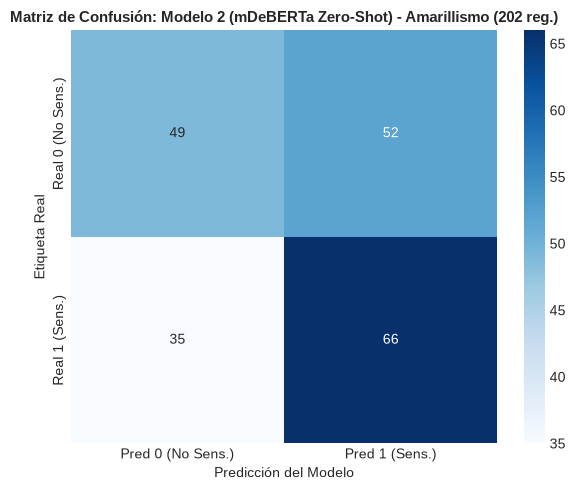

In [10]:
# Modelo 2 en Dataset 2: Amarillismo (202 registros reales balanceados)
t0 = time.time()
pred_m2_ama = evaluar_modelo2(df_amarillismo[col_text_ama].tolist(), batch_size=16)
tiempo_m2_ama = time.time() - t0

registrar_metricas("Modelo 2 (mDeBERTa Zero-Shot)", "Dataset 2: Amarillismo", y_amarillismo, pred_m2_ama, tiempo_m2_ama)

print(f"=== Modelo 2 - Dataset Amarillismo (202 registros) - Tiempo: {tiempo_m2_ama:.2f}s ===")
print(classification_report(y_amarillismo, pred_m2_ama, target_names=['No Amarillista (0)', 'Amarillista (1)'], digits=4))

cm_m2_ama = confusion_matrix(y_amarillismo, pred_m2_ama)
guardar_matriz_confusion(cm_m2_ama, "Matriz de Confusión: Modelo 2 (mDeBERTa Zero-Shot) - Amarillismo (202 reg.)", "cm_m2_amarillismo.png", cmap='Blues')


=== Modelo 2 - Dataset IA (70 registros) - Tiempo: 10.24s ===
                        precision    recall  f1-score   support

No sensacionalista (0)     0.8889    0.6857    0.7742        35
   Sensacionalista (1)     0.7442    0.9143    0.8205        35

              accuracy                         0.8000        70
             macro avg     0.8165    0.8000    0.7974        70
          weighted avg     0.8165    0.8000    0.7974        70



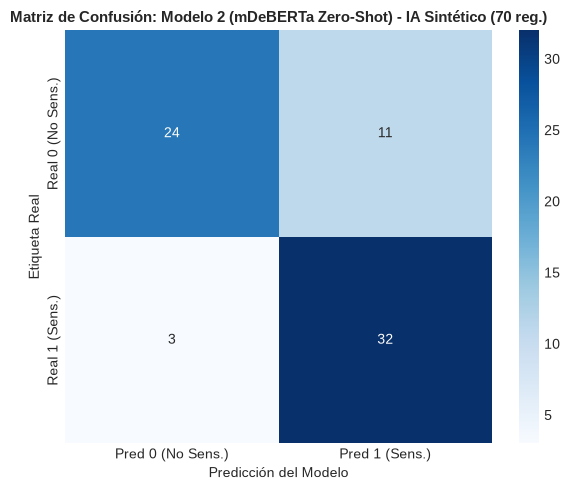

In [11]:
# Modelo 2 en Dataset 3: Creado con IA (70 registros)
t0 = time.time()
pred_m2_ia = evaluar_modelo2(df_ia['Texto'].tolist(), batch_size=16)
tiempo_m2_ia = time.time() - t0

registrar_metricas("Modelo 2 (mDeBERTa Zero-Shot)", "Dataset 3: IA Sintético", y_ia, pred_m2_ia, tiempo_m2_ia)

print(f"=== Modelo 2 - Dataset IA (70 registros) - Tiempo: {tiempo_m2_ia:.2f}s ===")
print(classification_report(y_ia, pred_m2_ia, target_names=['No sensacionalista (0)', 'Sensacionalista (1)'], digits=4))

cm_m2_ia = confusion_matrix(y_ia, pred_m2_ia)
guardar_matriz_confusion(cm_m2_ia, "Matriz de Confusión: Modelo 2 (mDeBERTa Zero-Shot) - IA Sintético (70 reg.)", "cm_m2_ia.png", cmap='Blues')

# Liberación de memoria VRAM
del modelo2_pipeline
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


--- 
# MODELO 3: Umbral Emocional (pysentimiento / robertuito)


In [12]:
print("Cargando Modelo 3: pysentimiento/robertuito-emotion-analysis...")
modelo3_pipeline = pipeline("text-classification", model="pysentimiento/robertuito-emotion-analysis", device=device, top_k=None, torch_dtype=torch_dtype)
print("¡Modelo 3 Emociones cargado correctamente en GPU!")

def evaluar_modelo3(textos, batch_size=32):
    res_list = modelo3_pipeline(textos, truncation=True, max_length=512, batch_size=batch_size)
    preds = []
    for res in res_list:
        scores = {d["label"]: d["score"] for d in res}
        impacto = scores.get("fear", 0.0) + scores.get("surprise", 0.0) + scores.get("anger", 0.0)
        pred = 1 if (impacto > 0.45 and scores.get("others", 0.0) < 0.30) else 0
        preds.append(pred)
    return preds


Cargando Modelo 3: pysentimiento/robertuito-emotion-analysis...


Loading weights:   0%|                                 | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|█████████████████████| 201/201 [00:00<00:00, 8454.31it/s]

¡Modelo 3 Emociones cargado correctamente en GPU!


=== Modelo 3 - Dataset Salud (2.200 registros) - Tiempo: 29.99s ===
                        precision    recall  f1-score   support

No sensacionalista (0)     0.5207    0.9991    0.6846      1120
   Sensacionalista (1)     0.9804    0.0463    0.0884      1080

              accuracy                         0.5314      2200
             macro avg     0.7505    0.5227    0.3865      2200
          weighted avg     0.7464    0.5314    0.3919      2200



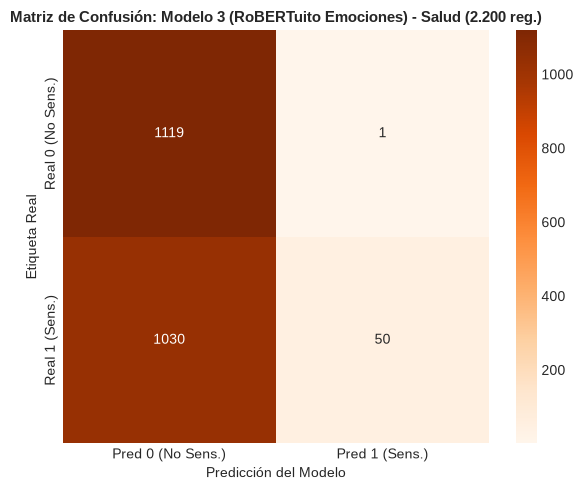

In [13]:
# Modelo 3 en Dataset 1: Salud (2.200 registros)
t0 = time.time()
pred_m3_salud = evaluar_modelo3(df_salud['encabezado'].tolist(), batch_size=32)
tiempo_m3_salud = time.time() - t0

registrar_metricas("Modelo 3 (RoBERTuito Emociones)", "Dataset 1: Salud", y_salud, pred_m3_salud, tiempo_m3_salud)

print(f"=== Modelo 3 - Dataset Salud (2.200 registros) - Tiempo: {tiempo_m3_salud:.2f}s ===")
print(classification_report(y_salud, pred_m3_salud, target_names=['No sensacionalista (0)', 'Sensacionalista (1)'], digits=4))

cm_m3_salud = confusion_matrix(y_salud, pred_m3_salud)
guardar_matriz_confusion(cm_m3_salud, "Matriz de Confusión: Modelo 3 (RoBERTuito Emociones) - Salud (2.200 reg.)", "cm_m3_salud.png", cmap='Oranges')


=== Modelo 3 - Dataset Amarillismo (202 registros) - Tiempo: 2.93s ===
                    precision    recall  f1-score   support

No Amarillista (0)     0.5000    1.0000    0.6667       101
   Amarillista (1)     0.0000    0.0000    0.0000       101

          accuracy                         0.5000       202
         macro avg     0.2500    0.5000    0.3333       202
      weighted avg     0.2500    0.5000    0.3333       202



/home/ubuntu/Documentos/Tesis/venv_pipeline/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/Documentos/Tesis/venv_pipeline/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/Documentos/Tesis/venv_pipeline/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

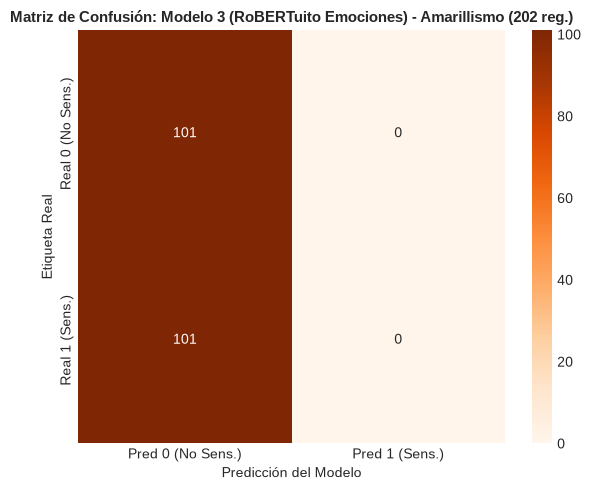

In [14]:
# Modelo 3 en Dataset 2: Amarillismo (202 registros reales balanceados)
t0 = time.time()
pred_m3_ama = evaluar_modelo3(df_amarillismo[col_text_ama].tolist(), batch_size=32)
tiempo_m3_ama = time.time() - t0

registrar_metricas("Modelo 3 (RoBERTuito Emociones)", "Dataset 2: Amarillismo", y_amarillismo, pred_m3_ama, tiempo_m3_ama)

print(f"=== Modelo 3 - Dataset Amarillismo (202 registros) - Tiempo: {tiempo_m3_ama:.2f}s ===")
print(classification_report(y_amarillismo, pred_m3_ama, target_names=['No Amarillista (0)', 'Amarillista (1)'], digits=4))

cm_m3_ama = confusion_matrix(y_amarillismo, pred_m3_ama)
guardar_matriz_confusion(cm_m3_ama, "Matriz de Confusión: Modelo 3 (RoBERTuito Emociones) - Amarillismo (202 reg.)", "cm_m3_amarillismo.png", cmap='Oranges')


=== Modelo 3 - Dataset IA (70 registros) - Tiempo: 1.40s ===
                        precision    recall  f1-score   support

No sensacionalista (0)     0.7292    1.0000    0.8434        35
   Sensacionalista (1)     1.0000    0.6286    0.7719        35

              accuracy                         0.8143        70
             macro avg     0.8646    0.8143    0.8077        70
          weighted avg     0.8646    0.8143    0.8077        70



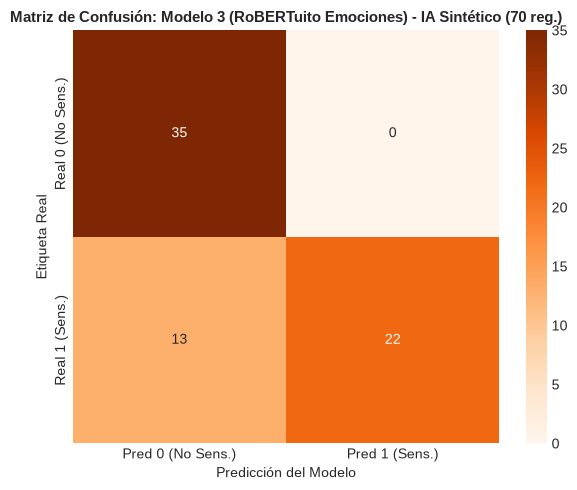

In [15]:
# Modelo 3 en Dataset 3: Creado con IA (70 registros)
t0 = time.time()
pred_m3_ia = evaluar_modelo3(df_ia['Texto'].tolist(), batch_size=32)
tiempo_m3_ia = time.time() - t0

registrar_metricas("Modelo 3 (RoBERTuito Emociones)", "Dataset 3: IA Sintético", y_ia, pred_m3_ia, tiempo_m3_ia)

print(f"=== Modelo 3 - Dataset IA (70 registros) - Tiempo: {tiempo_m3_ia:.2f}s ===")
print(classification_report(y_ia, pred_m3_ia, target_names=['No sensacionalista (0)', 'Sensacionalista (1)'], digits=4))

cm_m3_ia = confusion_matrix(y_ia, pred_m3_ia)
guardar_matriz_confusion(cm_m3_ia, "Matriz de Confusión: Modelo 3 (RoBERTuito Emociones) - IA Sintético (70 reg.)", "cm_m3_ia.png", cmap='Oranges')

# Liberación de memoria VRAM
del modelo3_pipeline
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


--- 
# TABLA COMPARATIVA GENERAL Y GRÁFICOS GLOBALES


In [16]:
df_resumen = pd.DataFrame(resultados_globales)
print("=== TABLA COMPARATIVA GENERAL DE RENDIMIENTO ===")
display(df_resumen)


=== TABLA COMPARATIVA GENERAL DE RENDIMIENTO ===


,Modelo,Dataset,N° Registros,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Tiempo Total (s),Latencia (ms)
0,Modelo 1 (BERT JJNeila),Dataset 1: Salud,2200,0.5568,0.6445,0.5636,0.4887,32.96,15.0
1,Modelo 1 (BERT JJNeila),Dataset 2: Amarillismo,202,0.5495,0.6525,0.5495,0.4580,3.31,16.4
2,Modelo 1 (BERT JJNeila),Dataset 3: IA Sintético,70,1.0000,1.0000,1.0000,1.0000,1.44,20.6
3,Modelo 2 (mDeBERTa Zero-Shot),Dataset 1: Salud,2200,0.6023,0.6343,0.6064,0.5823,247.02,112.3
4,Modelo 2 (mDeBERTa Zero-Shot),Dataset 2: Amarillismo,202,0.5693,0.5713,0.5693,0.5662,22.34,110.6
5,Modelo 2 (mDeBERTa Zero-Shot),Dataset 3: IA Sintético,70,0.8000,0.8165,0.8000,0.7974,10.24,146.3
6,Modelo 3 (RoBERTuito Emociones),Dataset 1: Salud,2200,0.5314,0.7505,0.5227,0.3865,29.99,13.6
7,Modelo 3 (RoBERTuito Emociones),Dataset 2: Amarillismo,202,0.5000,0.2500,0.5000,0.3333,2.93,14.5
8,Modelo 3 (RoBERTuito Emociones),Dataset 3: IA Sintético,70,0.8143,0.8646,0.8143,0.8077,1.40,20.0


findfont: Failed to find font weight semibold for Liberation Sans, now using 700.


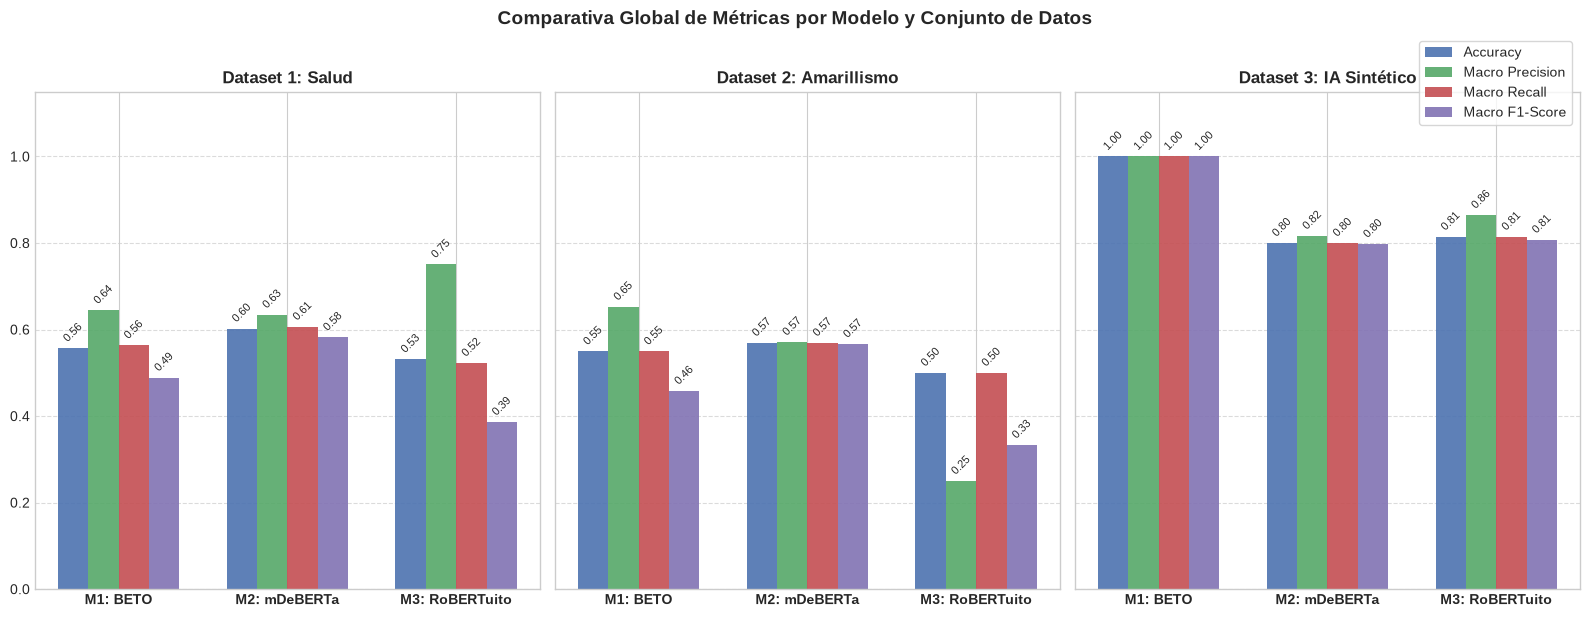

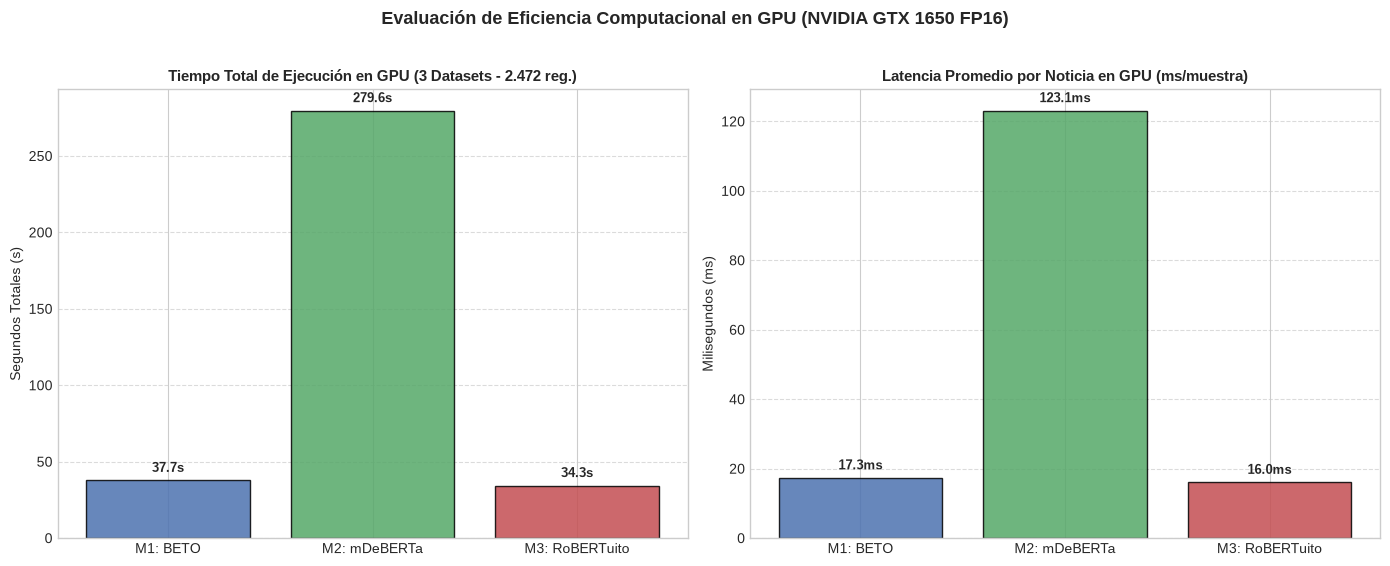

In [17]:
# 1. Gráfico Comparativo Global de Métricas
modelos_unicos = ["Modelo 1 (BERT JJNeila)", "Modelo 2 (mDeBERTa Zero-Shot)", "Modelo 3 (RoBERTuito Emociones)"]
metricas = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-Score"]
colores = ["#4c72b0", "#55a868", "#c44e52", "#8172b3"]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
datasets = ["Dataset 1: Salud", "Dataset 2: Amarillismo", "Dataset 3: IA Sintético"]

for idx, d_name in enumerate(datasets):
    ax = axes[idx]
    sub_df = df_resumen[df_resumen["Dataset"] == d_name]
    x = np.arange(len(modelos_unicos))
    width = 0.18
    
    for m_idx, met in enumerate(metricas):
        vals = [sub_df[sub_df["Modelo"] == mod][met].values[0] if len(sub_df[sub_df["Modelo"] == mod]) > 0 else 0 for mod in modelos_unicos]
        bars = ax.bar(x + (m_idx - 1.5) * width, vals, width, label=met if idx == 0 else "", color=colores[m_idx], alpha=0.9)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.annotate(f"{h:.2f}",
                            xy=(bar.get_x() + bar.get_width() / 2, h),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8, rotation=45)
    
    ax.set_title(d_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(["M1: BETO", "M2: mDeBERTa", "M3: RoBERTuito"], fontsize=10, fontweight='semibold')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.legend(loc="upper right", bbox_to_anchor=(0.99, 0.98), frameon=True)
plt.suptitle("Comparativa Global de Métricas por Modelo y Conjunto de Datos", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
for d in img_dirs:
    fig.savefig(os.path.join(d, "comparativa_metricas_sensacionalismo.png"), dpi=300, bbox_inches='tight')
plt.show()

# 2. Gráfico Comparativo de Tiempos e Inferencia (Tiempo Total y Latencia por Muestra)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
colores_modelos = ['#4c72b0', '#55a868', '#c44e52']

# Tiempo Total acumulado por modelo en los 3 datasets
tiempos_totales_modelo = [df_resumen[df_resumen["Modelo"] == mod]["Tiempo Total (s)"].sum() for mod in modelos_unicos]
latencia_promedio_modelo = [df_resumen[df_resumen["Modelo"] == mod]["Latencia (ms)"].mean() for mod in modelos_unicos]

ax1.bar(["M1: BETO", "M2: mDeBERTa", "M3: RoBERTuito"], tiempos_totales_modelo, color=colores_modelos, edgecolor='black', alpha=0.85)
ax1.set_title("Tiempo Total de Ejecución en GPU (3 Datasets - 2.472 reg.)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Segundos Totales (s)", fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(tiempos_totales_modelo):
    ax1.text(i, v + max(tiempos_totales_modelo) * 0.02, f"{v:.1f}s", ha='center', fontweight='bold', fontsize=9)

ax2.bar(["M1: BETO", "M2: mDeBERTa", "M3: RoBERTuito"], latencia_promedio_modelo, color=colores_modelos, edgecolor='black', alpha=0.85)
ax2.set_title("Latencia Promedio por Noticia en GPU (ms/muestra)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Milisegundos (ms)", fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(latencia_promedio_modelo):
    ax2.text(i, v + max(latencia_promedio_modelo) * 0.02, f"{v:.1f}ms", ha='center', fontweight='bold', fontsize=9)

plt.suptitle("Evaluación de Eficiencia Computacional en GPU (NVIDIA GTX 1650 FP16)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
for d in img_dirs:
    fig.savefig(os.path.join(d, "comparativa_tiempos_sensacionalismo.png"), dpi=300, bbox_inches='tight')
plt.show()
